## Esercizio 2) SVD per la compressione di immagini

### Consegna: 
Implementa il codice per caricare un'immagine in scala di grigi e calcolare la sua approssimazione mediante diadi.
- Carica l'immagine `data.camera()` di `skimage` e normalizzala con valori in [0, 1];
- Guarda l'immagine originale;
- Grafica i valori signolari (usa sia `plt.plot()`  che `plt.semilogy()`);
- Approssima l'immagine usando $k=5$ diadi;
- Confronta l'approssimazione con l'immagine originale e calcola l'errore relativo di approssimazione (norma di Frobenius);
- Guarda le prime 4 diadi.

Poi:
- Cambiando $k$, guarda e calcola come varia la compressione dell'immagine;
- Ripeti l'esercizio con altre immagini (ad esempio `data.coffee()` o `data.coins()`).



### Caricamento dell'immagine

Occorre installare il pacchetto `scikit-image`, che nel codice si importa come `skimage`.

Nel terminale, con l'ambiente Conda attivo: `conda install scikit-image`

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import data

img = data.camera()  
print(type(img))
print(img.shape)

print(f"Valori dell'immagine in [{np.max(img)}, {np.min(img)}]")

<class 'numpy.ndarray'>
(512, 512)
Valori dell'immagine in [255, 0]


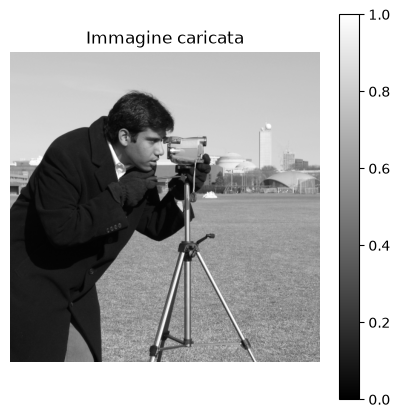

In [18]:
if np.max(img) > 1:
    img = img / np.max(img)

plt.figure(figsize=(5, 5))     
plt.imshow(img, cmap='gray')                 
plt.title('Immagine caricata')
plt.colorbar()
plt.axis('off')
plt.show()

### SVD dell'immagine

In [19]:
U_img, s_img, VT_img = np.linalg.svd(img, full_matrices=False)
print(U_img.shape)

(512, 512)


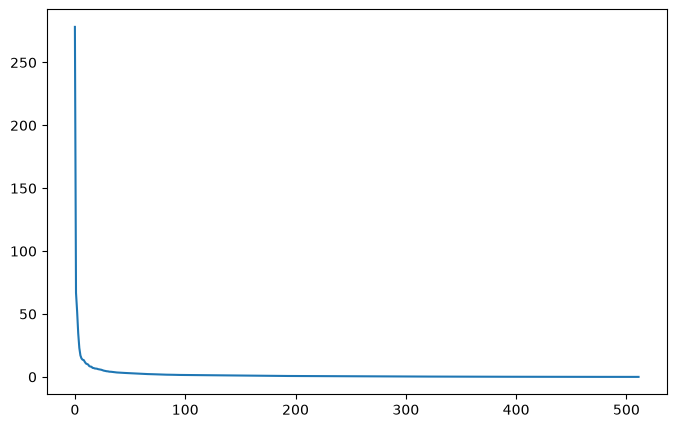

In [28]:
# Visualizzo i valori singolari
plt.figure(figsize=(8, 5)) 
plt.plot(s_img)
#plt.ylim([0,1])
plt.show()

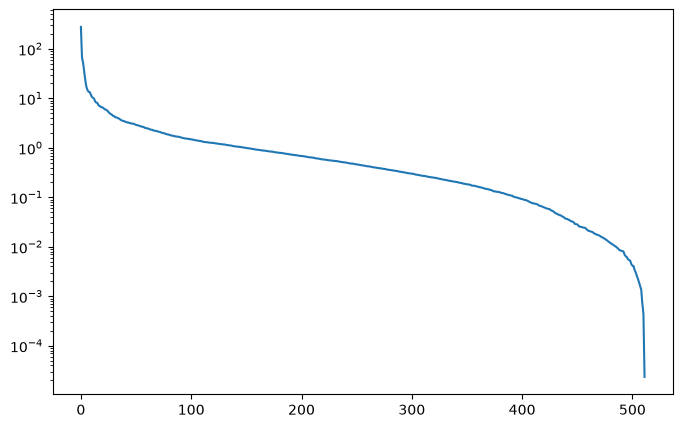

In [29]:
plt.figure(figsize=(8, 5)) 
plt.semilogy(s_img)
plt.show()

### Approssimazione con diadi

In [36]:
def approssimazione_svd(k):
    img = (U_img[:, :k] * s_img[:k]) @ VT_img[:k, :]
    return img

k= 5
img_approx = approssimazione_svd(k)



Errore Relativo con 5 diadi: 0.1720


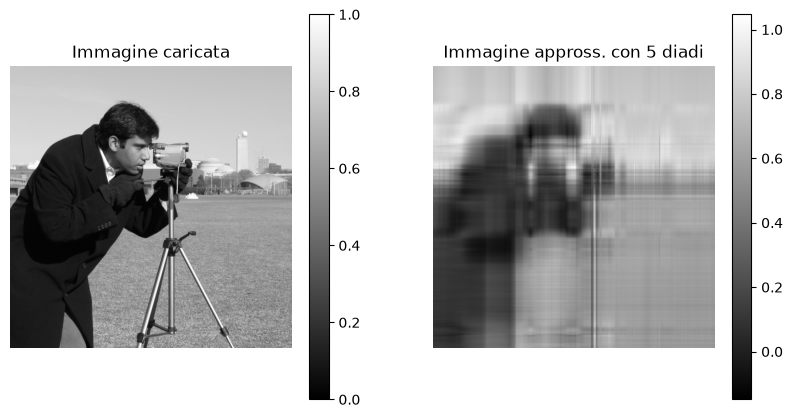

In [39]:
# Calcolo errore
erroreRel = np.linalg.norm(img-img_approx, 'fro') / np.linalg.norm(img, 'fro')
print(f"Errore Relativo con {k} diadi: {erroreRel:1.4f}")

# Visualizzo
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)   
plt.imshow(img, cmap='gray')                 
plt.title('Immagine caricata')
plt.colorbar()
plt.axis('off')
plt.grid()

plt.subplot(1, 2, 2)   
plt.imshow(img_approx, cmap='gray')                 
plt.title(f'Immagine appross. con {k} diadi')
plt.colorbar()
plt.axis('off')
plt.grid()

plt.show()

0
1
2
3


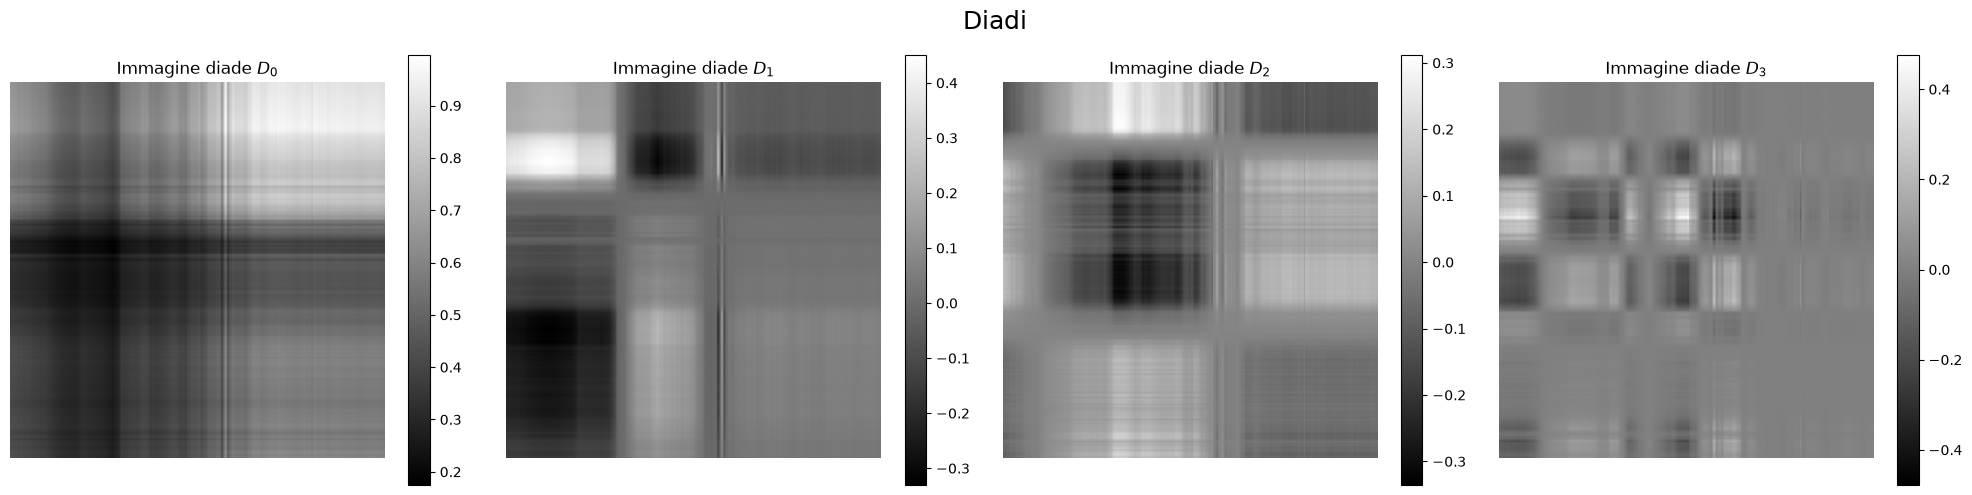

In [40]:
diadi_img = []

for i in range(4):
    print(i)
    diade = s_img[i] * np.outer(U_img[:, i], VT_img[i, :])
    diadi_img.append(diade)


# Visualizzo
plt.figure(figsize=(20, 5))
plt.subplot(1, 4, 1)  
plt.imshow(diadi_img[0], cmap='gray')                 
plt.title(f'Immagine diade $D_0$')
plt.colorbar()
plt.axis('off')
plt.grid()

plt.subplot(1, 4, 2)  
plt.imshow(diadi_img[1], cmap='gray')                 
plt.title(f'Immagine diade $D_1$')
plt.colorbar()
plt.axis('off')
plt.grid()

plt.subplot(1, 4, 3)  
plt.imshow(diadi_img[2], cmap='gray')                 
plt.title(f'Immagine diade $D_2$')
plt.colorbar()
plt.axis('off')
plt.grid()

plt.subplot(1, 4, 4)  
plt.imshow(diadi_img[3], cmap='gray')                 
plt.title(f'Immagine diade $D_3$')
plt.colorbar()
plt.axis('off')
plt.grid()

plt.suptitle('Diadi', fontsize=18)
plt.tight_layout()
plt.show()

(512, 512)


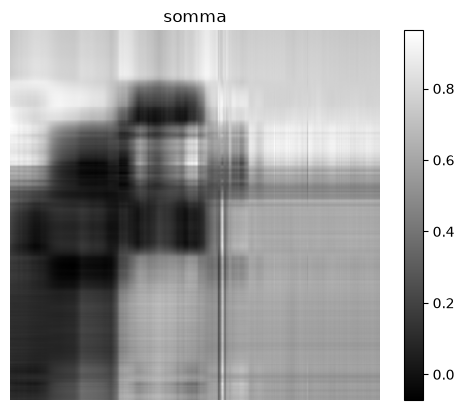

In [48]:
IMG = np.sum(diadi_img,0)
print(IMG.shape)

plt.imshow(IMG, cmap='gray')                 
plt.title(f'somma')
plt.colorbar()
plt.axis('off')
plt.grid()
